# <div align="center"><u>Project 11 - Version 3</u>
    
- The following analysis focuses on the binary classification of healthy individuals versus cancer patients. The specific pathology addressed is Pancreatic Ductal Adenocarcinoma (PDAC), which accounts for approximately 90% of all pancreatic cancer cases. Due to the asymptomatic nature of its early stages, early detection remains a significant hurdle. Consequently, it is a high-priority challenge for researchers to develop machine learning algorithms and diagnostic solutions capable of identifying the disease in its infancy.
    
- The dataset utilized in this study consists of synthetic data, generated to reflect real-world clinical distributions. Each record adheres to established medical parameters and biological constraints observed in Pancreatic Ductal Adenocarcinoma (PDAC) patients and healthy controls. Additionally, several non-oncological parameters were included to introduce noise into the dataset. This allows for a more rigorous evaluation of the machine learning algorithms' effectiveness and their ability to maintain predictive accuracy in the presence of irrelevant features:
    
    - Well-established bioindicators:
        - CA19-9, 12.5(±8.0) for healthy, 450(±210) for cancer, primary pancreatic rumor marker.
        - CEA, 1.8(±1.2) for healthy, 8.5(±5.5) for cancer, general marker for GI tract cancer.
        - Bilirubin(Total), 0.6(±0.3) for healthy, 2.4(±1.8) for cancer, elevated if tumor blocks bile ducts.
        - Alkaline Phosphatase, 70.0(±20.0) for healthy, 210.0(±95.0) for cancer, indicates liver/bile duct stress.
        - ALT (Alanine Aminotransferase), 25.0(±10.0) for healthy, 55.0(±30.0) for cancer, marker for secondary liver impact.
        - Albumin, 4.4(±0.4) for healthy, 3.2(±0.7) for cancer, drops due to inflammation/malnutrition.
        - CRP (C-Reactive Protein), 1.5(±1.0) for healthy, 15.0(±12.0) for cancer, general systemic inflammation marker.
        - Glucose (Fasting), 90.0(±10.0) for healthy, 135.0(±40.0) for cancer, New-onset diabetes is a PDAC sympton.
        - Hemoglobin, 14.5(±1.5) for healthy, 11.5(±2.0) for cancer, cancer often causes mild anemia.
        - Platelet Count, 250(±60) for healthy, 380(±110) for cancer, paraneoplastic thrombocytosis (high platelets).
    - Noise bioindicators:
        - Vitamin B12, 450.0(±150.0) for healthy, 450(±160) for cancer, Generally unaffected by early PDAC.
        - TSH (Thyroid), 2.1(±1.1) for healthy, 2.2(±1.2) for cancer, standard thyroid function marker.
        - Calcium, 9.5(±0.5) for healthy, 9.4(±0.6) for cancer, bone/parathyroid marker.
        - Chloride, 102.0(±3.0) for healthy, 101.5(±3.5) for cancer, basic electrolyte balance.
        - Potassium, 4.1(±0.4) for healthy, 4.0(±0.5) for cancer, marker essential mineral/electrolyte.
        - Creatinine, 0.9(±0.2) for healthy, 1.0(±0.3) for cancer, primary marker for kidney function.
        - HDL Cholesterol, 55.0(±12.0) for healthy, 53.0(±14.0) for cancer, "good" cholesterol;lipid profile.
        - HBA1c, 5.3(±0.4) for healthy, 5.5(±0.6) for cancer, 3-month average blood sugar.
        - Vitamin D, 32.0(±10.0) for healthy, 30.0(±12.0) for cancer, bone and immune health.
        - Uric acid, 5.0(±1.2) for healthy, 5.2(±1.4) for cancer, metabolic byproduct;gout marker.
    - More noise bioindicators:
        - Sodium, 140.0(±3.0) for healthy, 139.5(±3.5) for cancer, basic electrolyte.
        - Magnesium: 2.0 (±0.3) for healthy, 1.9 (±0.4) for cancer, mineral balance.
        - Phosphorus: 3.5 (±0.5) for healthy, 3.6 (±0.6) for cancer, bone/kidney marker.
        - Total Protein: 7.2 (±0.5) for healthy, 7.0 (±0.8) for cancer, general nutrition.
        - BUN: 15.0 (±4.0) for healthy, 16.0 (±5.0) for cancer, blood urea nitrogen (kidney).
        - LDL Cholesterol: 100.0 (±25.0) for healthy, 105.0 (±30.0) for cancer, "bad" cholesterol.
        - Triglycerides: 130.0 (±40.0) for healthy, 135.0 (±50.0) for cancer, lipid profile.
        - Erythrocytes: 5.0 (±0.5) for healthy, 4.8 (±0.7) for cancer, red blood cell count.
        - MCV: 90.0 (±5.0) for healthy, 89.0 (±7.0) for cancer, average size of RBCs.
        - Platelet Vol: 10.5 (±1.2) for healthy, 10.8 (±1.5) for cancer, size of platelets.
        - Monocytes: 6.0 (±2.0) for healthy, 6.2 (±2.5) for cancer, general white blood cell type.
        - Basophils: 0.5 (±0.3) for healthy, 0.6 (±0.4) for cancer, allergy/inflammation marker.
        - Eosinophils: 2.5 (±1.5) for healthy, 2.4 (±1.8) for cancer, parasitic/allergic response.
        - Ferritin: 100.0 (±50.0) for healthy, 105.0 (±60.0) for cancer, iron storage.
        - Transferrin: 250.0 (±40.0) for healthy, 245.0 (±50.0) for cancer, iron transport.
        - Iron: 100.0 (± 30.0) for healthy, 98.0 (±35.0) for cancer, serum iron levels.
        - Urea: 30.0 (±10.0) for healthy, 32.0 (±12.0) for cancer, protein breakdown product.
        - Gamma-GT: 30.0 (±15.0) for healthy, 35.0 (±20.0) for cancer, liver enzyme.
        - CPK: 120.0 (±40.0) for healthy, 115.0 (±45.0) for cancer, muscle enzyme.
        - CO2: 26.0 (±2.0) for healthy, 25.5 (±2.5) for cancer, acid-base balance.

##############################################################################################################################

###  Import libraries

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import random
import time

import random
import time

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, log_loss, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score

### Suppress warnings

In [56]:
# Suppress all warnings
import warnings

warnings.filterwarnings("ignore")

### Start time

In [57]:
# Start time
start_time = time.time()

### Create some data

In [58]:
# Set seed for reproducibility
np.random.seed(42)

# Function that generates data based on real life spectrum values
def generate_data(n_samples, label):
    data = {
        # --- Cancer-Related Indicators (High Signal) ---
        'CA_19_9':       np.random.normal(12.5 if label == 0 else 450.0, 8.0 if label == 0 else 210.0, n_samples),
        'CEA':           np.random.normal(1.8  if label == 0 else 8.5,   1.2 if label == 0 else 5.5,   n_samples),
        'Bilirubin':     np.random.normal(0.6  if label == 0 else 2.4,   0.3 if label == 0 else 1.8,   n_samples),
        'Alkaline_Phos': np.random.normal(70.0 if label == 0 else 210.0, 20.0 if label == 0 else 95.0, n_samples),
        'ALT':           np.random.normal(25.0 if label == 0 else 55.0,  10.0 if label == 0 else 30.0, n_samples),
        'Albumin':       np.random.normal(4.4  if label == 0 else 3.2,   0.4 if label == 0 else 0.7,   n_samples),
        'CRP':           np.random.normal(1.5  if label == 0 else 15.0,  1.0 if label == 0 else 12.0,  n_samples),
        'Glucose':       np.random.normal(90.0 if label == 0 else 135.0, 10.0 if label == 0 else 40.0, n_samples),
        'Hemoglobin':    np.random.normal(14.5 if label == 0 else 11.5,  1.5 if label == 0 else 2.0,   n_samples),
        'Platelets':     np.random.normal(250  if label == 0 else 380,   60  if label == 0 else 110,   n_samples),
        
        # --- Non-Related Indicators (Low Signal/Noise) ---
        'Vitamin_B12': np.random.normal(450.0 if label == 0 else 445.0, 150.0 if label == 0 else 160.0, n_samples),
        'TSH':         np.random.normal(2.1   if label == 0 else 2.2,   1.1   if label == 0 else 1.2,   n_samples),
        'Calcium':     np.random.normal(9.5   if label == 0 else 9.4,   0.5   if label == 0 else 0.6,   n_samples),
        'Chloride':    np.random.normal(102.0 if label == 0 else 101.5, 3.0   if label == 0 else 3.5,   n_samples),
        'Potassium':   np.random.normal(4.1   if label == 0 else 4.0,   0.4   if label == 0 else 0.5,   n_samples),
        'Creatinine':  np.random.normal(0.9   if label == 0 else 1.0,   0.2   if label == 0 else 0.3,   n_samples),
        'HDL_Chol':    np.random.normal(55.0  if label == 0 else 53.0,  12.0  if label == 0 else 14.0,  n_samples),
        'HBA1c':       np.random.normal(5.3   if label == 0 else 5.5,   0.4   if label == 0 else 0.6,   n_samples),
        'Vitamin_D':   np.random.normal(32.0  if label == 0 else 30.0,  10.0  if label == 0 else 12.0,  n_samples),
        'Uric_Acid':   np.random.normal(5.0   if label == 0 else 5.2,   1.2   if label == 0 else 1.4,   n_samples),
        
        # --- Non-Related Indicators (Low Signal/Noise) ---
        'Sodium':        np.random.normal(140.0 if label == 0 else 139.5, 3.0  if label == 0 else 3.5, n_samples),
        'Magnesium':     np.random.normal(2.0   if label == 0 else 1.9,   0.3  if label == 0 else 0.4, n_samples),
        'Phosphorus':    np.random.normal(3.5   if label == 0 else 3.6,   0.5  if label == 0 else 0.6, n_samples),
        'Total_Protein': np.random.normal(7.2   if label == 0 else 7.0,   0.5  if label == 0 else 0.8, n_samples),
        'BUN':           np.random.normal(15.0  if label == 0 else 16.0,  4.0  if label == 0 else 5.0, n_samples),
        'LDL_Chol':      np.random.normal(100.0 if label == 0 else 105.0, 25.0 if label == 0 else 30.0, n_samples),
        'Triglycerides': np.random.normal(130.0 if label == 0 else 135.0, 40.0 if label == 0 else 50.0, n_samples),
        'Erythrocytes':  np.random.normal(5.0   if label == 0 else 4.8,   0.5  if label == 0 else 0.7, n_samples),
        'MCV':           np.random.normal(90.0  if label == 0 else 89.0,  5.0  if label == 0 else 7.0, n_samples),
        'Platelet_Vol':  np.random.normal(10.5  if label == 0 else 10.8,  1.2  if label == 0 else 1.5, n_samples),
        'Monocytes':     np.random.normal(6.0   if label == 0 else 6.2,   2.0  if label == 0 else 2.5, n_samples),
        'Basophils':     np.random.normal(0.5   if label == 0 else 0.6,   0.3  if label == 0 else 0.4, n_samples),
        'Eosinophils':   np.random.normal(2.5   if label == 0 else 2.4,   1.5  if label == 0 else 1.8, n_samples),
        'Ferritin':      np.random.normal(100.0 if label == 0 else 105.0, 50.0 if label == 0 else 60.0, n_samples),
        'Transferrin':   np.random.normal(250.0 if label == 0 else 245.0, 40.0 if label == 0 else 50.0, n_samples),
        'Iron':          np.random.normal(100.0 if label == 0 else 98.0,  30.0 if label == 0 else 35.0, n_samples),
        'Urea':          np.random.normal(30.0  if label == 0 else 32.0,  10.0 if label == 0 else 12.0, n_samples),
        'Gamma_GT':      np.random.normal(30.0  if label == 0 else 35.0,  15.0 if label == 0 else 20.0, n_samples),
        'CPK':           np.random.normal(120.0 if label == 0 else 115.0, 40.0 if label == 0 else 45.0, n_samples),
        'CO2':           np.random.normal(26.0  if label == 0 else 25.5,  2.0  if label == 0 else 2.5, n_samples),
        
        'Target': [label] * n_samples
    }
    return pd.DataFrame(data) # Added return statement

# Set number of samples for each
n_samples = 100

# Generate 100 samples for each
healthy_df = generate_data(n_samples, 0) # 0 = Healthy
cancer_df = generate_data(n_samples, 1)  # 1 = Cancer (PDAC)

# Combine and shuffle
df = pd.concat([healthy_df, cancer_df]).sample(frac=1).reset_index(drop=True)

# Ensure no negative values (biological constraint)
df[df.columns[:-1]] = df[df.columns[:-1]].clip(lower=0.1)

df

,CA_19_9,CEA,Bilirubin,Alkaline_Phos,ALT,Albumin,CRP,Glucose,Hemoglobin,Platelets,...,Basophils,Eosinophils,Ferritin,Transferrin,Iron,Urea,Gamma_GT,CPK,CO2,Target
0,27.318225,1.882276,0.664938,52.054913,4.607678,3.735392,3.029550,80.216272,13.122022,362.869424,...,0.488729,0.100000,22.713511,303.849030,155.731070,23.657142,17.577056,98.868118,29.056063,0
1,15.356901,0.771411,0.798639,58.012147,15.444596,4.233885,0.370948,76.646556,13.703697,275.527454,...,0.656643,2.545047,159.527430,145.874516,139.940172,26.064701,25.099557,127.021449,29.281229,0
2,454.752479,14.803166,1.938587,214.214086,34.949644,2.369105,15.814062,110.665969,13.012977,322.992210,...,0.208280,6.661346,77.984797,297.610558,159.070149,34.825470,41.654387,140.968248,26.337636,1
3,19.075220,2.792620,0.738631,54.653049,22.509640,3.515546,0.722183,74.297753,17.191837,136.627556,...,0.274269,4.533164,48.798570,198.616629,108.608676,30.728741,37.073136,167.675973,26.383155,0
4,16.606139,0.100000,0.413190,58.461927,33.816398,4.057566,1.944263,73.390391,16.163055,251.613150,...,1.048886,2.067942,106.953020,186.096033,88.113110,28.482856,49.549171,153.984480,24.450770,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,302.007029,7.616529,1.457284,158.126029,93.514506,2.990573,0.100000,96.007737,14.220232,371.084944,...,0.501310,2.825056,108.492764,229.702278,99.042866,7.821185,30.912885,200.615119,27.111725,1
196,802.521681,3.845022,4.486886,146.649372,29.645381,3.195832,32.652416,67.373135,9.795226,411.545152,...,0.891909,5.940451,86.239370,217.060209,97.012374,29.418634,37.159678,172.851201,25.317856,1
197,650.907669,6.364663,0.276973,148.670653,75.875915,2.753689,0.100000,173.313585,11.685958,439.772991,...,0.806458,4.715488,123.084424,259.697469,60.349217,26.986604,1.564775,77.890735,27.623961,1
198,303.378068,5.699327,0.100000,226.738033,63.574099,2.510826,8.082965,146.662547,14.247829,477.578775,...,0.456417,4.862570,128.722421,259.775585,121.353580,22.333680,55.304418,104.256133,24.239678,1


### Define parameters

In [59]:
# Define parameters
number_of_splits = 50       # Number of MCCV iterations
test_size = 0.25            # 25% test data
number_of_neighbors = 11      # Number of neighbors

### Prepare data

In [60]:
# Prepare data
X = df.iloc[:, :-1].values  # Features
y = df['Target'].values     # Classes-Labels

### Function that applies Monte Carlo Cross Validation (MCCV)

In [61]:
# Function that applies Monte Carlo Cross Validation
def kNN_MCCV(X, y, n_neighbors, test_size, num_splits): # Removed default values from def for clarity with external variables
    
    train_scores = np.zeros(num_splits)
    test_scores = np.zeros(num_splits)
    train_losses = np.zeros(num_splits)
    test_losses = np.zeros(num_splits)

    test_precision_scores = np.zeros(num_splits)
    test_recall_scores = np.zeros(num_splits)
    test_f1_scores = np.zeros(num_splits)
    test_auc_roc_scores = np.zeros(num_splits)

    labels = np.unique(y)
    n_classes = len(labels)
    cm_total = np.zeros((n_classes, n_classes), dtype=np.float64)

    for i in range(num_splits):
        x_train, x_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, shuffle=True, stratify=y, random_state=i
        )

        scaler = StandardScaler()
        x_train_scaled = scaler.fit_transform(x_train)
        x_test_scaled = scaler.transform(x_test)

        model = KNeighborsClassifier(n_neighbors=n_neighbors)
        model.fit(x_train_scaled, y_train)

        y_train_pred = model.predict(x_train_scaled)
        y_test_pred = model.predict(x_test_scaled)

        # Calculate accuracy for train and test
        train_scores[i] = accuracy_score(y_train, y_train_pred)
        test_scores[i] = accuracy_score(y_test, y_test_pred)

        # Calculate and store precision, recall, f1_score and AUC-ROC metrics for the test set
        test_precision_scores[i] = precision_score(y_test, y_test_pred, average='binary', labels=labels, zero_division=0)
        test_recall_scores[i] = recall_score(y_test, y_test_pred, average='binary', labels=labels, zero_division=0)
        test_f1_scores[i] = f1_score(y_test, y_test_pred, average='binary', labels=labels, zero_division=0)
        
        # If predict_proba is available
        if hasattr(model, "predict_proba"):
            y_train_proba = model.predict_proba(x_train_scaled)
            y_test_proba = model.predict_proba(x_test_scaled)

            test_auc_roc_scores[i] = roc_auc_score(y_test, y_test_proba[:, 1])
                
        else:
            test_auc_roc_scores[i] = np.nan

        cm = confusion_matrix(y_test, y_test_pred, labels=labels)
        cm_total += cm

    cm_avg = cm_total / num_splits
    
    return (
        train_scores,
        test_scores,
        test_precision_scores, 
        test_recall_scores,     
        test_f1_scores,         
        test_auc_roc_scores,    
        cm_avg,
        labels,
    )

### Apply MCCV

In [62]:
# Apply MCCV for kNN
train_scores, test_scores, \
test_precision_scores, test_recall_scores, test_f1_scores, test_auc_roc_scores, \
cm_avg, labels = kNN_MCCV(
    X, y, n_neighbors=number_of_neighbors, test_size=test_size, num_splits=number_of_splits
)

### Print results

In [63]:
print(f"Avg Training Accuracy: {np.mean(train_scores):.4f} ± {np.std(train_scores):.4f}")
print(f"Avg Evaluation Accuracy:  {np.mean(test_scores):.4f} ± {np.std(test_scores):.4f}")
print("")
print(f"Avg Evaluation Precision: {np.mean(test_precision_scores):.4f} ± {np.std(test_precision_scores):.4f}")
print(f"Avg Evaluation Recall:    {np.mean(test_recall_scores):.4f} ± {np.std(test_recall_scores):.4f}")
print(f"Avg Evaluation F1-Score:  {np.mean(test_f1_scores):.4f} ± {np.std(test_f1_scores):.4f}")
print(f"Avg Evaluation AUC-ROC:   {np.mean(test_auc_roc_scores):.4f} ± {np.std(test_auc_roc_scores):.4f}")

Avg Training Accuracy: 0.8656 ± 0.0200
Avg Evaluation Accuracy:  0.8360 ± 0.0386

Avg Evaluation Precision: 1.0000 ± 0.0000
Avg Evaluation Recall:    0.6720 ± 0.0771
Avg Evaluation F1-Score:  0.8013 ± 0.0545
Avg Evaluation AUC-ROC:   0.9972 ± 0.0069


### Accuracy over MCCV iterations

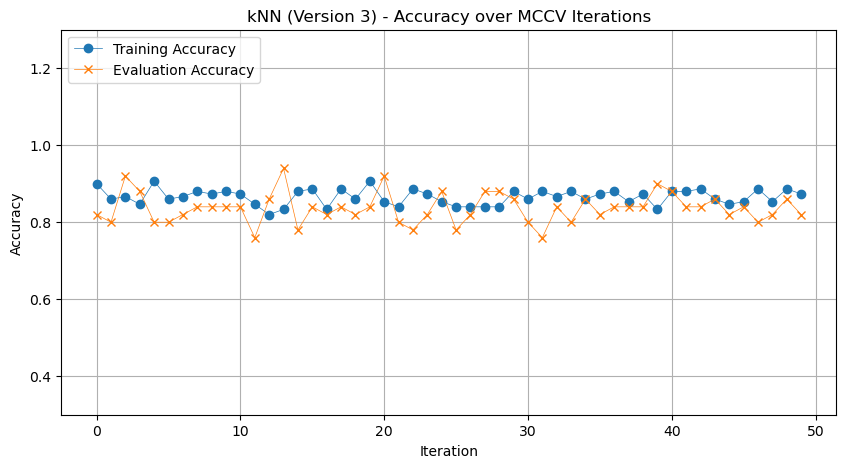

In [64]:
# Accuracy over MCCV iterations
plt.figure(figsize=(10, 5))
plt.plot(train_scores, label='Training Accuracy', marker='o', linewidth=0.5)
plt.plot(test_scores, label='Evaluation Accuracy', marker='x', linewidth=0.5)
plt.title("kNN (Version 3) - Accuracy over MCCV Iterations")
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.legend(loc='upper left')
plt.ylim(0.3, 1.3)
plt.show()

### Plot the average confussion matrix

In [65]:
# Function that plots the average confussion matrix
def plot_confusion_matrix(cm, labels, title='kNN (Version 3) MCCV - Average Confusion Matrix', cmap='Blues'):
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='.2f', cmap=cmap,
                xticklabels=labels,
                yticklabels=labels)

    plt.title(title, fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.tight_layout()
    plt.show()

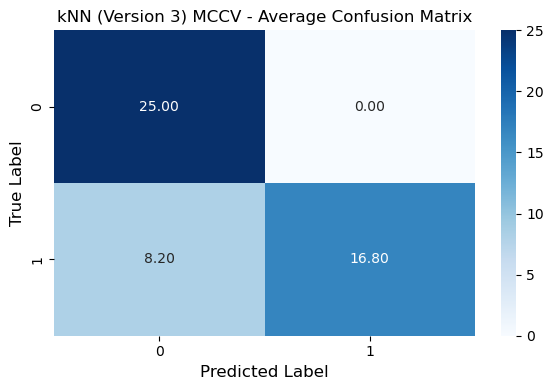

In [66]:
# Plot confusion matrix
plot_confusion_matrix(cm_avg, labels)

### End time

In [67]:
# End time
end_time = time.time()

### Elapsed time

In [68]:
# Elapsed time
elapsed_time = end_time - start_time

print(f"Elapsed time for kNN (Version 3): {elapsed_time:.2f} seconds")

Elapsed time for kNN (Version 3): 20.68 seconds
